<div style="background-color: #1F3864; padding: 20px; border-radius: 5px; margin-bottom: 20px;">
    <h1 style="color: white; margin: 0; font-size: 24px;">16. GDP Deflator & NSDP Processing</h1>
    <p style="color: #cce0ff; margin: 8px 0 0 0; font-size: 14px;">Produces two independent, saved output files used by retrospective notebooks: (1) a national GDP deflator series for inflation-adjusting the CWC damage time series and refitting f(R), and (2) a single-year regional NSDP exposure snapshot for the cross-sectional exposure figure.</p>
</div>

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 1: National GDP Deflator (World Bank NY.GDP.DEFL.ZS)</h2>
</div>

In [1]:
import pandas as pd
from pathlib import Path

# File is the UNLINKED series: NY.GDP.DEFL.ZS (NOT the .ZS.AD "linked series")
WB_CSV_PATH = Path("../data/raw/gdp_deflator_wb_ind.csv")

# Matches convention used in notebooks 01-15
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# World Bank WDI CSV format: 4 metadata lines, then header row, then one row per country.
# Header row (0-indexed row 4) has: Country Name, Country Code, Indicator Name, Indicator Code, then year columns.
wb_raw = pd.read_csv(WB_CSV_PATH, skiprows=4, encoding="utf-8-sig")

india_row = wb_raw.loc[wb_raw["Country Code"] == "IND"]
assert len(india_row) == 1, f"Expected exactly one India row, found {len(india_row)}"

year_cols = [c for c in wb_raw.columns if c.isdigit()]
deflator_long = (
    india_row[year_cols]
    .T
    .reset_index()
    .rename(columns={"index": "year", india_row.index[0]: "deflator_index"})
)
deflator_long["year"] = deflator_long["year"].astype(int)
deflator_long = deflator_long.dropna(subset=["deflator_index"]).reset_index(drop=True)

print(f"Coverage: {deflator_long['year'].min()}–{deflator_long['year'].max()} "
      f"({len(deflator_long)} years)")
deflator_long.head()

Coverage: 1960–2025 (66 years)


,year,deflator_index
0,1960,1.480741
1,1961,1.512509
2,1962,1.579145
3,1963,1.711060
4,1964,1.857385


In [ ]:
# Sanity check: confirm no unexpected gaps in year coverage
expected_years = set(range(deflator_long["year"].min(), deflator_long["year"].max() + 1))
actual_years = set(deflator_long["year"])
missing = sorted(expected_years - actual_years)
print("Missing years within range:", missing if missing else "none")

# Known limitation to carry into the write-up: World Bank coverage starts 1960.
# CWC damage record starts 1953 -> 1953-1959 (7 years) will have no deflator value.
# So will plot raw nominal CWC series for full 1953-2023 range, overlay the
# inflation-adjusted line from 1960 onward only, with this gap documented in the caption.
cwc_start_year = 1953
gap_years = [y for y in range(cwc_start_year, deflator_long["year"].min()) ]
print(f"Years in CWC record with no deflator coverage: {gap_years}")

Missing years within range: none
Years in CWC record with no deflator coverage: [1953, 1954, 1955, 1956, 1957, 1958, 1959]


In [4]:
deflator_out_path = OUTPUT_DIR / "gdp_deflator_national.csv"
deflator_long.to_csv(deflator_out_path, index=False)
print(f"Saved: {deflator_out_path}")

Saved: ../outputs/gdp_deflator_national.csv


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 2: Regional NSDP Exposure Snapshot (RBI Table 5)</h2>
</div>

In [5]:
# the RBI NSDP file
NSDP_PATH = Path("../data/raw/nsdp_statewise_current_prices.xlsx")


# Choosing the snapshot year (must be within the 2011-12-base block, i.e. 2011-12 to 2025-26)... a recent, non-COVID year 
SNAPSHOT_YEAR = "2019-20"

In [9]:
import openpyxl

wb_nsdp = openpyxl.load_workbook(NSDP_PATH, data_only=True)
ws = wb_nsdp["Report 1"]

# Header row (Excel row 8): "Year", then state/UT names
header = [ws.cell(row=8, column=c).value for c in range(2, 36)]
header = [str(h).strip() if h is not None else h for h in header]

# Data rows start at Excel row 10 (row 9 is a "1,2,3..." column-index row, skipped).
# The current (2011-12-base) block ends where column B goes blank -- read until that point.
records = []
r = 10
while True:
    year_val = ws.cell(row=r, column=2).value
    if year_val is None:
        break
    row_vals = [ws.cell(row=r, column=c).value for c in range(2, 36)]
    records.append(row_vals)
    r += 1

nsdp_block = pd.DataFrame(records, columns=header)
nsdp_block["Year"] = nsdp_block["Year"].astype(str).str.strip()

print(f"Current (2011-12-base) block: {len(nsdp_block)} years, "
      f"{nsdp_block['Year'].iloc[-1]} -> {nsdp_block['Year'].iloc[0]}")
nsdp_block.head()

Current (2011-12-base) block: 15 years, 2011-12 -> 2025-26


/home/ucfadod@ad.ucl.ac.uk/.local/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Year,Andhra Pradesh,Arunachal Pradesh,Assam,Bihar,Chhattisgarh,Goa,Gujarat,Haryana,Himachal Pradesh,...,Tamil Nadu,Telangana,Tripura,Uttar Pradesh,Uttarakhand,West Bengal,Andaman & Nicobar Islands,Chandigarh,Delhi,Puducherry
0,2025-26,1.579501e+06,44129.176549,-,1.003951e+06,556873.88,-,2.636003e+06,-,-,...,3.160206e+06,1.614771e+06,-,-,327143.422934,1.799664e+06,-,-,-,-
1,2024-25,1.425452e+06,39428.639790,576920.0595,8.975950e+05,500335.25,101044.7948,2.384203e+06,1087269.415149,194343.9639,...,2.792496e+06,1.457913e+06,78616.70583,2630444.604,296469.985400,1.638832e+06,11687.66091,61146.6,1082815.045,47963.84329
2,2023-24,1.274642e+06,33319.735390,516544.986022,7.951304e+05,455034.81,85635.67896,2.159266e+06,971534.224515,175592.3728,...,2.412414e+06,1.321694e+06,70562.72426,2324537.834,272114.724300,1.492645e+06,11108.60965,56080.61,988100.7058,42035.73209
3,2022-23,1.166752e+06,31794.850000,432471.402581,6.883717e+05,401888.67,74007.92153,1.920900e+06,869315.38293,159590.0013,...,2.113128e+06,1.185734e+06,63399.6336,1986461.127,251688.606800,1.360627e+06,10612.15313,50083.52,884269.3383,37690.72996
4,2021-22,1.012119e+06,29391.090000,364269.3519,5.872046e+05,366688.54,71756.31592,1.698072e+06,787402.9236,143400.0744,...,1.854762e+06,1.017251e+06,56046.27,1766957.263,223247.293000,1.209217e+06,9205.756324,40994.84,771350.2567,36886.96657


In [10]:
snapshot_row = nsdp_block.loc[nsdp_block["Year"] == SNAPSHOT_YEAR]
assert len(snapshot_row) == 1, (
    f"Expected exactly one row for {SNAPSHOT_YEAR}, found {len(snapshot_row)}. "
    f"Available years in this block: {nsdp_block['Year'].tolist()}"
)

state_cols = [c for c in nsdp_block.columns if c != "Year"]
snapshot = snapshot_row[state_cols].T.reset_index()
snapshot.columns = ["state", "nsdp_current_prices_rs_crore"]

# Check for any missing-data markers ('-') before converting to numeric
non_numeric = snapshot.loc[~snapshot["nsdp_current_prices_rs_crore"].apply(
    lambda v: isinstance(v, (int, float)))]
print("Non-numeric entries (should be empty for a clean snapshot year):")
print(non_numeric)

snapshot["nsdp_current_prices_rs_crore"] = pd.to_numeric(
    snapshot["nsdp_current_prices_rs_crore"], errors="coerce")
snapshot

Non-numeric entries (should be empty for a clean snapshot year):
Empty DataFrame
Columns: [state, nsdp_current_prices_rs_crore]
Index: []


,state,nsdp_current_prices_rs_crore
0,Andhra Pradesh,8.280334e+05
1,Arunachal Pradesh,2.752608e+04
2,Assam,3.110315e+05
3,Bihar,5.325733e+05
4,Chhattisgarh,3.086174e+05
5,Goa,6.735418e+04
6,Gujarat,1.437478e+06
7,Haryana,6.651767e+05
8,Himachal Pradesh,1.366919e+05
9,Jammu & Kashmir,1.351069e+05


In [11]:
# The same STATE_TO_REGION dict from 05_cwc_damage_aggregation.ipynb (cell 3):

STATE_TO_REGION = {
    "Kerala": "Western_Ghats", "Karnataka": "Western_Ghats", "Goa": "Western_Ghats", "Maharashtra": "Western_Ghats",
    "Madhya Pradesh": "Central_India", "Chhattisgarh": "Central_India", "Odisha": "Central_India", "Jharkhand": "Central_India",
    "Uttar Pradesh": "Indo_Gangetic_Plain", "Bihar": "Indo_Gangetic_Plain", "West Bengal": "Indo_Gangetic_Plain",
    "Punjab": "Indo_Gangetic_Plain", "Haryana": "Indo_Gangetic_Plain", "Delhi": "Indo_Gangetic_Plain",
    "Assam": "Northeast", "Meghalaya": "Northeast", "Arunachal Pradesh": "Northeast", "Tripura": "Northeast",
}

unmapped = sorted(set(snapshot["state"]) - set(STATE_TO_REGION.keys()))
print(f"States not assigned to any of the four regions ({len(unmapped)}):")
print(unmapped)

States not assigned to any of the four regions (15):
['Andaman & Nicobar Islands', 'Andhra Pradesh', 'Chandigarh', 'Gujarat', 'Himachal Pradesh', 'Jammu & Kashmir', 'Manipur', 'Mizoram', 'Nagaland', 'Puducherry', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Uttarakhand']


In [12]:
snapshot["region"] = snapshot["state"].map(STATE_TO_REGION)

regional_snapshot = (
    snapshot.dropna(subset=["region"])
    .groupby("region", as_index=False)["nsdp_current_prices_rs_crore"]
    .sum()
)
regional_snapshot["year"] = SNAPSHOT_YEAR
regional_snapshot["nsdp_lakh_crore"] = regional_snapshot["nsdp_current_prices_rs_crore"] / 100000

regional_snapshot

,region,nsdp_current_prices_rs_crore,year,nsdp_lakh_crore
0,Central_India,1.909345e+06,2019-20,19.093454
1,Indo_Gangetic_Plain,5.002272e+06,2019-20,50.022717
2,Northeast,4.185079e+05,2019-20,4.185079
3,Western_Ghats,4.595147e+06,2019-20,45.951466


In [13]:
# Quick check: total across all states/UTs should land close to (but below) national GDP
# for the same year - NSDP excludes depreciation and items not allocated to any state.
national_nsdp_total = pd.to_numeric(snapshot["nsdp_current_prices_rs_crore"], errors="coerce").sum()
print(f"Sum of all states/UTs, {SNAPSHOT_YEAR}: Rs {national_nsdp_total/100000:.1f} lakh crore")
print("Cross-check this against independently reported national GDP for the same year ")

Sum of all states/UTs, 2019-20: Rs 181.9 lakh crore
Cross-check this against independently reported national GDP for the same year 


In [14]:
# Compute each region's share of the 4-region NSDP total, and compare against
# the damage-share numbers from 14_state_level_scatter_gdp.ipynb ("full record" totals).
# Damage shares are hardcoded here, NOT recomputed - they come from that notebook's
# printed output: Total damage by region (full record) -> Share of national total.
DAMAGE_SHARE_PCT = {
    "Central_India": 7.877772,
    "Indo_Gangetic_Plain": 46.888858,
    "Northeast": 18.118130,
    "Western_Ghats": 27.115241,
}

regional_snapshot["nsdp_share_pct"] = (
    regional_snapshot["nsdp_current_prices_rs_crore"]
    / regional_snapshot["nsdp_current_prices_rs_crore"].sum() * 100
)
regional_snapshot["damage_share_pct"] = regional_snapshot["region"].map(DAMAGE_SHARE_PCT)
regional_snapshot["gap_pp"] = regional_snapshot["damage_share_pct"] - regional_snapshot["nsdp_share_pct"]

regional_snapshot

,region,nsdp_current_prices_rs_crore,year,nsdp_lakh_crore,nsdp_share_pct,damage_share_pct,gap_pp
0,Central_India,1.909345e+06,2019-20,19.093454,16.010917,7.877772,-8.133145
1,Indo_Gangetic_Plain,5.002272e+06,2019-20,50.022717,41.946816,46.888858,4.942042
2,Northeast,4.185079e+05,2019-20,4.185079,3.509420,18.118130,14.608710
3,Western_Ghats,4.595147e+06,2019-20,45.951466,38.532847,27.115241,-11.417606


In [15]:
snapshot_out_path = OUTPUT_DIR / "nsdp_regional_snapshot.csv"
regional_snapshot.to_csv(snapshot_out_path, index=False)
print(f"Saved: {snapshot_out_path}")

Saved: ../outputs/nsdp_regional_snapshot.csv


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 3: Deflating the CWC Damage Series</h2>
</div>

In [16]:
CWC_PATH = OUTPUT_DIR / "cwc_extracted_long.csv"

cwc = pd.read_csv(CWC_PATH)
print(f"Loaded {len(cwc)} records, years {cwc['year'].min()}-{cwc['year'].max()}, "
      f"states: {cwc['state'].nunique()}")
cwc.head()

Loaded 1278 records, years 1953-2023, states: 18


,state,region,year,total_damages_cr,crops_damage_cr,houses_damage_cr,public_util_damage_cr
0,Arunachal Pradesh,Northeast,1953,0.0,0.0,0.0,NaN
1,Arunachal Pradesh,Northeast,1954,0.0,0.0,0.0,NaN
2,Arunachal Pradesh,Northeast,1955,0.0,0.0,0.0,NaN
3,Arunachal Pradesh,Northeast,1956,0.0,0.0,0.0,NaN
4,Arunachal Pradesh,Northeast,1957,0.0,0.0,0.0,NaN


In [17]:
# Deflator's own base year is 2022 (index = 100): express deflated values in "2022 rupees"
# directly off that, rather than choosing an arbitrary base year.
BASE_YEAR_INDEX = 100.0

cwc_deflated = cwc.merge(deflator_long, on="year", how="left")

damage_cols = [c for c in cwc.columns if c.endswith("_cr")]
for col in damage_cols:
    cwc_deflated[f"{col}_real_2022"] = (
        cwc_deflated[col] * (BASE_YEAR_INDEX / cwc_deflated["deflator_index"])
    )

n_no_deflator = cwc_deflated["deflator_index"].isna().sum()
print(f"Records with no deflator coverage (years 1953-1959): {n_no_deflator}")
print(f"Affected years: {sorted(cwc_deflated.loc[cwc_deflated['deflator_index'].isna(), 'year'].unique())}")

cwc_deflated.head()

Records with no deflator coverage (years 1953-1959): 126
Affected years: [np.int64(1953), np.int64(1954), np.int64(1955), np.int64(1956), np.int64(1957), np.int64(1958), np.int64(1959)]


,state,region,year,total_damages_cr,crops_damage_cr,houses_damage_cr,public_util_damage_cr,deflator_index,total_damages_cr_real_2022,crops_damage_cr_real_2022,houses_damage_cr_real_2022,public_util_damage_cr_real_2022
0,Arunachal Pradesh,Northeast,1953,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Arunachal Pradesh,Northeast,1954,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Arunachal Pradesh,Northeast,1955,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,Arunachal Pradesh,Northeast,1956,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Arunachal Pradesh,Northeast,1957,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
check_cols = ["state", "region", "year", "total_damages_cr", "total_damages_cr_real_2022"]
print("Recent year (real ~ nominal, both in 2022 rupees):")
print(cwc_deflated.loc[cwc_deflated["year"] == 2022, check_cols].head(3))
print()
print("Older year (real should be noticeably higher than nominal- inflation erodes old rupee values):")
sample_old_year = cwc_deflated.loc[cwc_deflated["year"] >= 1960, "year"].min()
print(f"(using {sample_old_year}, the earliest year with deflator coverage)")
print(cwc_deflated.loc[cwc_deflated["year"] == sample_old_year, check_cols].head(3))

Recent year (real ~ nominal, both in 2022 rupees):
                 state               region  year  total_damages_cr  \
69   Arunachal Pradesh            Northeast  2022              4.42   
140              Assam            Northeast  2022           2397.90   
211              Bihar  Indo_Gangetic_Plain  2022               NaN   

     total_damages_cr_real_2022  
69                         4.42  
140                     2397.90  
211                         NaN  

Older year (real should be noticeably higher than nominal- inflation erodes old rupee values):
(using 1960, the earliest year with deflator coverage)
                 state               region  year  total_damages_cr  \
7    Arunachal Pradesh            Northeast  1960              0.00   
78               Assam            Northeast  1960              7.76   
149              Bihar  Indo_Gangetic_Plain  1960              0.01   

     total_damages_cr_real_2022  
7                      0.000000  
78                   524

In [19]:
cwc_deflated_out_path = OUTPUT_DIR / "cwc_damage_deflated.csv"
cwc_deflated.to_csv(cwc_deflated_out_path, index=False)
print(f"Saved: {cwc_deflated_out_path}")

Saved: ../outputs/cwc_damage_deflated.csv


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 4: Exposure Choropleth Map</h2>
</div>

In [20]:
state_breakdown = snapshot.dropna(subset=["region"]).copy()

national_total = state_breakdown["nsdp_current_prices_rs_crore"].sum()
state_breakdown["state_share_of_national_pct"] = (
    state_breakdown["nsdp_current_prices_rs_crore"] / national_total * 100
)  # USE THIS for the choropleth's color scale -- enables cross-region comparison

state_breakdown["region_total_nsdp"] = state_breakdown.groupby("region")["nsdp_current_prices_rs_crore"].transform("sum")
state_breakdown["state_share_of_region_pct"] = (
    state_breakdown["nsdp_current_prices_rs_crore"] / state_breakdown["region_total_nsdp"] * 100
)  # companion number for text/annotations only -- e.g. "Maharashtra = X% of Western Ghats' total"

state_breakdown = state_breakdown.sort_values(
    ["region", "state_share_of_national_pct"], ascending=[True, False]
)

breakdown_out_path = OUTPUT_DIR / "nsdp_state_breakdown_by_region.csv"
state_breakdown.to_csv(breakdown_out_path, index=False)
print(f"Saved: {breakdown_out_path}")
state_breakdown

Saved: ../outputs/nsdp_state_breakdown_by_region.csv


,state,nsdp_current_prices_rs_crore,region,state_share_of_national_pct,region_total_nsdp,state_share_of_region_pct
13,Madhya Pradesh,8.448087e+05,Central_India,7.084188,1.909345e+06,44.245987
19,Odisha,4.729948e+05,Central_India,3.966323,1.909345e+06,24.772618
4,Chhattisgarh,3.086174e+05,Central_India,2.587927,1.909345e+06,16.163518
10,Jharkhand,2.829245e+05,Central_India,2.372478,1.909345e+06,14.817877
26,Uttar Pradesh,1.539808e+06,Indo_Gangetic_Plain,12.912141,5.002272e+06,30.782172
28,West Bengal,1.072956e+06,Indo_Gangetic_Plain,8.997328,5.002272e+06,21.449371
31,Delhi,7.128419e+05,Indo_Gangetic_Plain,5.977574,5.002272e+06,14.250364
7,Haryana,6.651767e+05,Indo_Gangetic_Plain,5.577875,5.002272e+06,13.297493
3,Bihar,5.325733e+05,Indo_Gangetic_Plain,4.465921,5.002272e+06,10.646628
20,Punjab,4.789161e+05,Indo_Gangetic_Plain,4.015976,5.002272e+06,9.573972


In [21]:
import geopandas as gpd

path = "/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/data/gadm/gadm41_IND.gpkg"
gdf = gpd.read_file(path, layer="ADM_ADM_1")
gdf_clean = gdf.dissolve(by="NAME_1")

print(f"Number of dissolved states/UTs: {len(gdf_clean)}")

Number of dissolved states/UTs: 36


In [22]:
# GADM/region_states uses "NCT of Delhi"; the RBI NSDP file uses plain "Delhi"- align before merging.
# Everything else (incl. Chhattisgarh, double-h) already matches between the two sources.
NAME_ALIGN = {"Delhi": "NCT of Delhi"}
state_breakdown["gadm_name"] = state_breakdown["state"].replace(NAME_ALIGN)
state_breakdown_indexed = state_breakdown.set_index("gadm_name")

gdf_exposure = gdf_clean.merge(
    state_breakdown_indexed, left_index=True, right_index=True, how="left"
)

unmatched = state_breakdown.loc[~state_breakdown["gadm_name"].isin(gdf_clean.index), "state"]
print(f"Study states not matched to GADM geometry (should be empty): {list(unmatched)}")
print(f"States with exposure data on the map: {gdf_exposure['region'].notna().sum()} / {len(state_breakdown)} expected")

Study states not matched to GADM geometry (should be empty): []
States with exposure data on the map: 18 / 18 expected


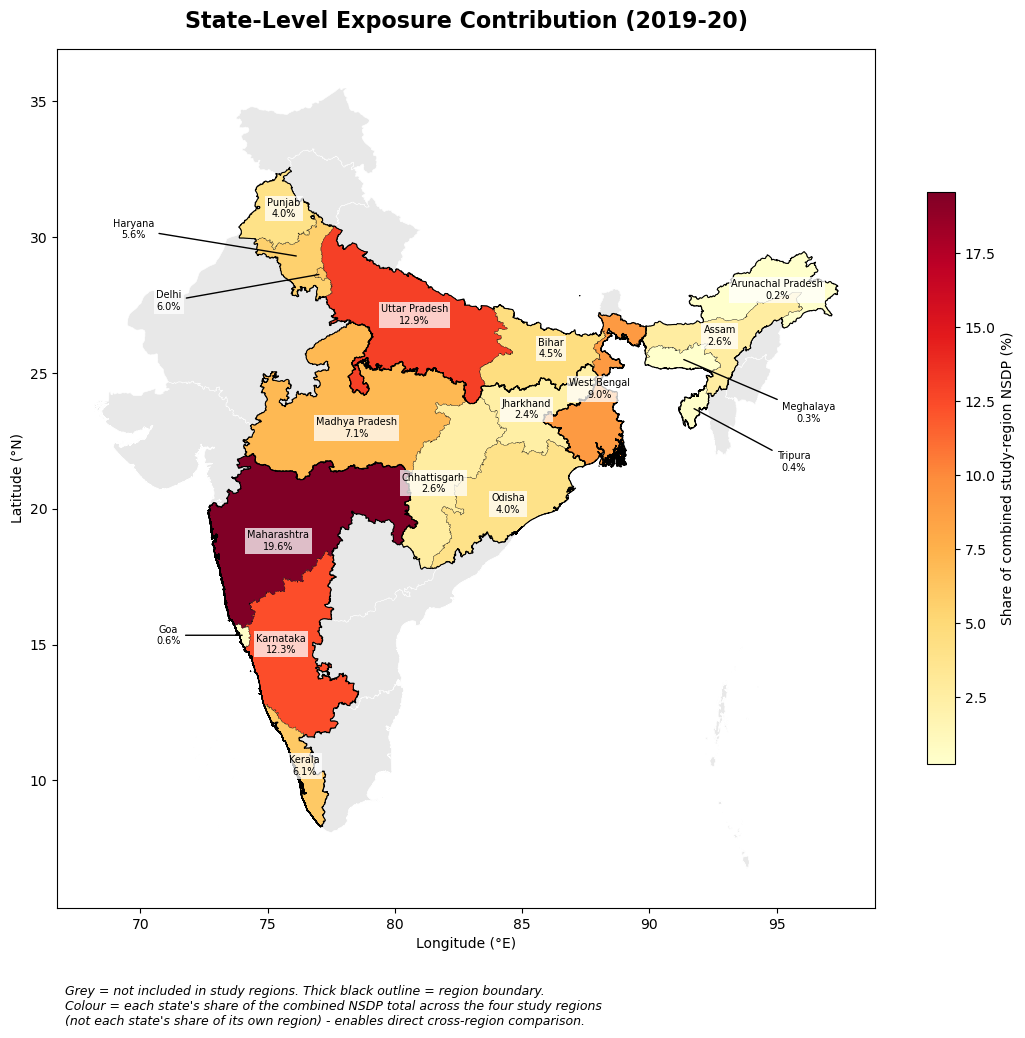

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

DISPLAY_NAMES = {"NCT of Delhi": "Delhi"}
LEADER_OFFSETS = {
    "Haryana": (-6.5, 1), "Goa": (-3, 0), "Tripura": (4, -2),
    "Meghalaya": (5, -2), "NCT of Delhi": (-6, -1),
}
label_style = dict(fontsize=7, fontweight="normal", color="black", ha="center", va="center",
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5))

fig, ax = plt.subplots(figsize=(11, 11))

# Base map: everything grey first
gdf_clean.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.4)

# Study states colored by % share of NATIONAL (4-region) NSDP total
# enables direct cross-region comparison.
study = gdf_exposure[gdf_exposure["region"].notna()]
study.plot(
    ax=ax, column="state_share_of_national_pct", cmap="YlOrRd",
    edgecolor="black", linewidth=0.2, legend=True,
    legend_kwds={"label": "Share of combined study-region NSDP (%)", "shrink": 0.6},
)

# Thicker outline around each REGION's combined boundary
region_outlines = study.dissolve(by="region")
region_outlines.boundary.plot(ax=ax, color="black", linewidth=0.8)

LABEL_OFFSETS = {
    "Assam": (2, 0.3),
    "Madhya Pradesh": (-0.9, -1),
}

for state, row in study.iterrows():
    pt = row.geometry.representative_point()
    label_text = DISPLAY_NAMES.get(state, state)
    pct_text = f"{row['state_share_of_national_pct']:.1f}%"
    combined_label = f"{label_text}\n{pct_text}"
    if state in LEADER_OFFSETS:
        dx, dy = LEADER_OFFSETS[state]
        ax.annotate(combined_label, xy=(pt.x, pt.y), xytext=(pt.x + dx, pt.y + dy),
                    arrowprops=dict(arrowstyle="-", color="black", lw=1), **label_style)
    elif state in LABEL_OFFSETS:
        dx, dy = LABEL_OFFSETS[state]
        ax.annotate(combined_label, xy=(pt.x + dx, pt.y + dy), **label_style)
    else:
        ax.annotate(combined_label, xy=(pt.x, pt.y), **label_style)

ax.set_title(f"State-Level Exposure Contribution ({SNAPSHOT_YEAR})", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.text(0.01, -0.09,
        "Grey = not included in study regions. Thick black outline = region boundary.\n"
        "Colour = each state's share of the combined NSDP total across the four study regions\n"
        "(not each state's share of its own region) - enables direct cross-region comparison.",
        transform=ax.transAxes, fontsize=9, style="italic", va="top")

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 5: Deflated Regional Aggregation (2000-2020, for f(R) Refit)</h2>
</div>

In [24]:
# Reproduces 05_cwc_damage_aggregation.ipynb cell 9's exact aggregation logic,
# on total_damages_cr_real_2022 instead of the raw total_damages_cr.
# Same window, same sum(min_count=1) behaviour, same generic reporting-completeness flag.
N_STATES = cwc_deflated.groupby("region")["state"].nunique().to_dict()

WINDOW = (2000, 2020)
cwc_deflated_w = cwc_deflated[cwc_deflated["year"].between(*WINDOW)]

agg_real = cwc_deflated_w.groupby(["region", "year"])["total_damages_cr_real_2022"].agg(
    regional_total_cr_real_2022=lambda x: x.sum(min_count=1),
    n_reporting=lambda x: x.notna().sum()
).reset_index()
agg_real["n_states_in_region"] = agg_real["region"].map(N_STATES)
agg_real["pct_states_reporting"] = (agg_real["n_reporting"] / agg_real["n_states_in_region"] * 100).round(0)

agg_real["data_quality_flag"] = ""
agg_real.loc[agg_real["pct_states_reporting"] < 100, "data_quality_flag"] = agg_real.loc[
    agg_real["pct_states_reporting"] < 100
].apply(lambda r: f"Only {r['n_reporting']}/{r['n_states_in_region']} states reporting", axis=1)

agg_real.loc[(agg_real.region == "Central_India") & (agg_real.year == 2000), "data_quality_flag"] += \
    "; Jharkhand data embedded in Bihar (IGP) pre-2001; Central_India total likely understated"
agg_real.loc[(agg_real.region == "Indo_Gangetic_Plain") & (agg_real.year == 2000), "data_quality_flag"] += \
    "; Bihar total may include former Jharkhand territory; IGP total likely overstated"

agg_real["data_quality_flag"] = agg_real["data_quality_flag"].str.replace(r'^; ', '', regex=True)

agg_real["data_quality_flag"] = agg_real["data_quality_flag"].str.replace(r'^ -- ', '', regex=True)

REGION_ORDER = ["Western_Ghats", "Central_India", "Indo_Gangetic_Plain", "Northeast"]
agg_real["region"] = pd.Categorical(agg_real["region"], categories=REGION_ORDER, ordered=True)
agg_real = agg_real.sort_values(["region", "year"]).reset_index(drop=True)

agg_out_path = OUTPUT_DIR / "cwc_regional_aggregated_FINAL_2000_2020_real2022.csv"
agg_real.to_csv(agg_out_path, index=False)

print(f"Saved: {agg_out_path}")
print(f"Rows: {len(agg_real)}, flagged: {(agg_real.data_quality_flag != '').sum()}")
agg_real.pivot(index="year", columns="region", values="regional_total_cr_real_2022").round(1)

Saved: ../outputs/cwc_regional_aggregated_FINAL_2000_2020_real2022.csv
Rows: 84, flagged: 15


region,Western_Ghats,Central_India,Indo_Gangetic_Plain,Northeast
year,,,,
2000,158.3,0.2,19451.0,834.1
2001,308.6,5299.5,12733.1,135.4
2002,187.9,9.5,5051.6,2376.5
2003,336.4,4740.0,5325.2,18736.4
2004,0.0,234.9,6672.3,2179.8
2005,4989.8,1800.1,2736.7,1444.5
2006,7943.1,5245.0,409.4,673.5
2007,12426.8,2944.6,5451.3,767.1
2008,1365.0,6683.4,2755.3,1137.6


In [25]:
agg_real[agg_real['data_quality_flag'] != ''][['region', 'year', 'n_reporting', 'n_states_in_region', 'pct_states_reporting', 'data_quality_flag']]

,region,year,n_reporting,n_states_in_region,pct_states_reporting,data_quality_flag
18,Western_Ghats,2018,3,4,75.0,Only 3/4 states reporting
19,Western_Ghats,2019,1,4,25.0,Only 1/4 states reporting
20,Western_Ghats,2020,2,4,50.0,Only 2/4 states reporting
21,Central_India,2000,2,4,50.0,Only 2/4 states reporting; Jharkhand data embe...
40,Central_India,2019,3,4,75.0,Only 3/4 states reporting
42,Indo_Gangetic_Plain,2000,6,6,100.0,Bihar total may include former Jharkhand terri...
47,Indo_Gangetic_Plain,2005,5,6,83.0,Only 5/6 states reporting
57,Indo_Gangetic_Plain,2015,5,6,83.0,Only 5/6 states reporting
58,Indo_Gangetic_Plain,2016,4,6,67.0,Only 4/6 states reporting
59,Indo_Gangetic_Plain,2017,5,6,83.0,Only 5/6 states reporting


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Outputs Produced by This Notebook</h2>
</div>

gdp_deflator_national.csv — columns: year, deflator_index (base year 2022 = 100). Coverage 1960-2025.
Feeds: the deflation step below, and can be used directly in 06_fR_fitting.ipynb if preferred.

nsdp_regional_snapshot.csv — columns: region, nsdp_current_prices_rs_crore, year, nsdp_lakh_crore,
nsdp_share_pct, damage_share_pct, gap_pp. Feeds: the standalone regional exposure comparison figure
(region NSDP share vs. region CWC damage share). Does not feed f(R)/Delta.

cwc_damage_deflated.csv — same rows/columns as cwc_extracted_long.csv, plus one _real_2022 column
per damage column (total/crops/houses/public_util), and the raw deflator_index used for each row.
Rows for years 1953-1959 have NaN in all _real_2022 columns (no deflator coverage, documented limitation).
Feeds: the national damage time series figure (real vs. nominal overlay), and the f(R) refit.

nsdp_state_breakdown_by_region.csv — per-state NSDP within each region, with both
state_share_of_national_pct (share of the combined 4-region total, used for the choropleth colour scale)
and state_share_of_region_pct (share of that state's own region total, companion number for text/annotations,
e.g. "Maharashtra = 89% of Western Ghats' total").

exposure_choropleth.png — state-level exposure map, coloured by state_share_of_national_pct, region
boundaries outlined, built in Part 4 by merging this notebook's NSDP breakdown onto the GADM geometry already
used in 03_regional_masks_and_approachA.ipynb.

Next notebooks in the rebuild cascade (same pattern as the domain-fix and Delhi-inclusion reruns):
06_fR_fitting.ipynb -> 08_damage_amplification.ipynb -> 13_fR_sensitivity_grid.ipynb, now loading
cwc_damage_deflated.csv and fitting on the _real_2022 columns instead of raw rupee figures.